# Heteroskedastic Simulation

We compare two variance-constrained empirical Bayes denoisers — one imposing a *marginal* variance constraint and one imposing a *conditional* variance constraint — on a simulated univariate heteroskedastic Gaussian data set. This reproduces the corresponding heteroskedastic simulation figure in the paper (see the figure-mapping table in the README).

In [1]:
from npeb.GLMixture import *
import numpy as np
import matplotlib.pyplot as plt
import cvxpy as cp
import scipy.stats as stats
from scipy.stats import norm

/Users/aqjaffe/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/aqjaffe/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


## Set up data

We sample the latent variables $\Theta_1,\ldots,\Theta_n$ from a standard Gaussian distribution $G=\mathcal{N}(0,1)$, and we sample the latent variances $\sigma_1^2,\ldots,\sigma_n^2$ from a two-point distribution equal to $0.5$ or $8$ with equal probability. Conditionally on these, we sample each observation from a Gaussian likelihood with mean $\theta_i$ and variance $\sigma_i^2$. The three panels below show the sampled latent variables, variances, and observations.

Text(0.5, 1.0, '$Z$')

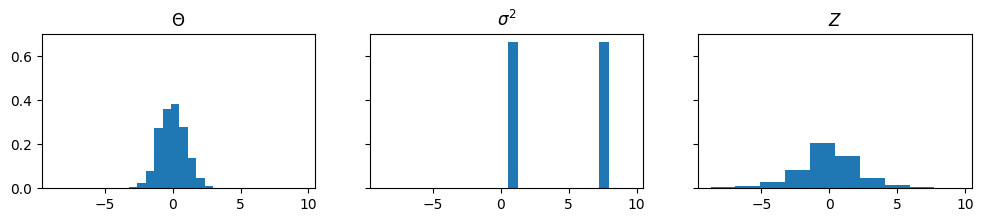

In [2]:
np.random.seed(22222)

n = 1500
var1, var2 = 0.5, 8.
xlim = 7.

Theta = np.random.normal(0,1,size=(n,1))
Sigma2 = var1 + (var2 - var1)*np.random.randint(0,2,size=(n,1))
Z = np.random.normal(Theta,np.sqrt(Sigma2),size=(n,1))

fig, ax = plt.subplots(1, 3, sharex=True, sharey=True, figsize=(12,2))

ax[0].hist(Theta, density=True)
ax[0].set_title('$\\Theta$')

ax[1].hist(Sigma2, density=True)
ax[1].set_title('$\sigma^2$')

ax[2].hist(Z, density=True)
ax[2].set_title('$Z$')

## Compute denoisers

We now compute the three denoisers of interest — the unconstrained denoiser, the marginal variance-constrained denoiser, and the conditional variance-constrained denoiser — with the help of the `npeb` package.

In [3]:
# (unconstrained) empirical Bayes
eb_model = GLMixture(prec_type='diagonal')
prec = 1./Sigma2
eb_model.fit(Z, prec)
eb = eb_model.posterior_mean(Z, prec)

In [4]:
# empirical marginal variance-constrained Bayes denoiser
eb_mean = np.mean(eb)
M_hat = np.var(eb)
at, wt = eb_model.get_params()
at = at.ravel()
mu_hat = np.sum(at * wt)
A_hat = np.sum(np.power(at - mu_hat,2)*wt)
transport_hat = np.sqrt(A_hat/M_hat)
eb_mcb = transport_hat*(eb - eb_mean) + mu_hat

In [5]:
# empirical conditional variance-constrained Bayes denoiser
eb_ccb = np.zeros_like(eb)
eb_ccb[Sigma2 == var1]
at, wt = eb_model.get_params()

for var in [var1, var2]:
    
    eb_mean = np.mean(eb[Sigma2 == var])
    M_hat = np.var(eb[Sigma2 == var])
    at = at.ravel()
    mu_hat = np.sum(at * wt)
    A_hat = np.sum(np.power(at - mu_hat,2) * wt)
    transport_hat = np.sqrt(A_hat/M_hat)
    eb_ccb[Sigma2 == var] = transport_hat*(eb[Sigma2 == var] - eb_mean) + mu_hat

## Plot

Finally, we plot the observations and the three denoisers, both for all observations and stratified into the low-variance and high-variance subsets. The marginal variance-constrained denoiser matches the latent variance only in aggregate, whereas the conditional version matches it within each subset.

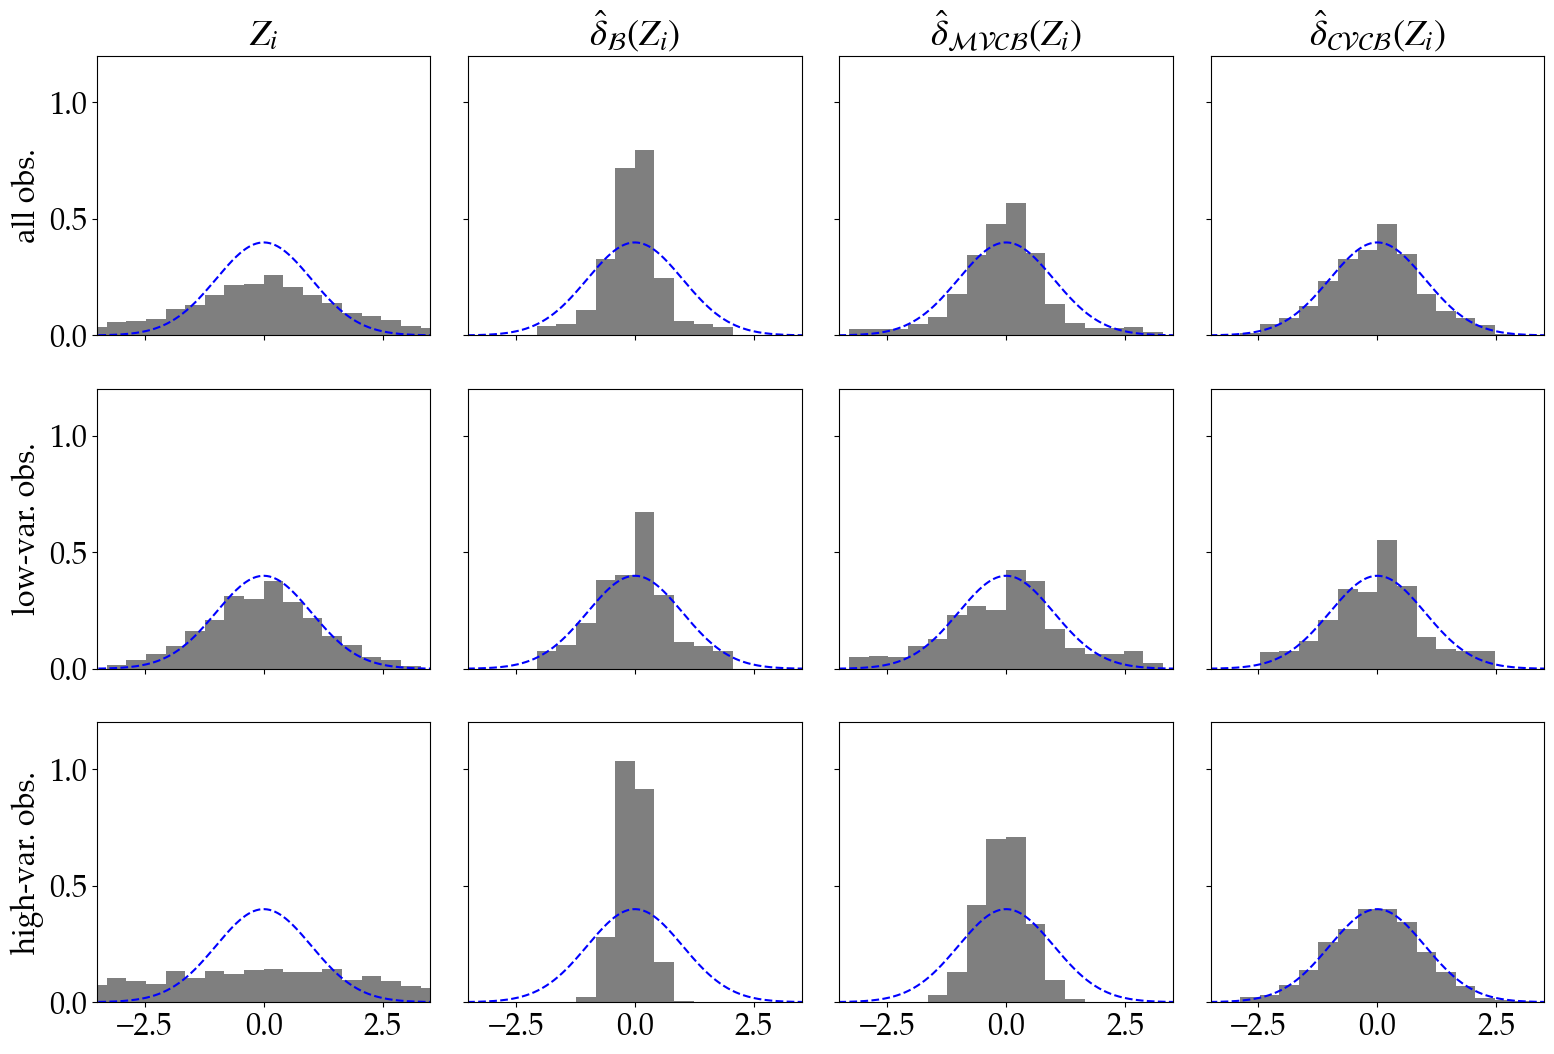

In [6]:
plt.rcParams.update({'font.size': 22,
                     'mathtext.fontset': 'stix',
                     'font.family': 'serif',
                     'font.serif':'Palatino'})

Z_alpha = 0.5
bins=np.linspace(-xlim,xlim,35)
fig, ax = plt.subplots(3, 4, sharex=True, sharey=True, figsize=(16,11))

ax[0,0].hist(Z, bins=bins, density=True, alpha=Z_alpha, color='black')
ax[0,0].set_ylabel('all obs.')
ax[0,1].hist(eb, bins=bins, density=True, alpha=Z_alpha, color='black')
ax[0,2].hist(eb_mcb, bins=bins, density=True, alpha=Z_alpha, color='black')
ax[0,3].hist(eb_ccb, bins=bins, density=True, alpha=Z_alpha, color='black')

ax[1,0].hist(Z[Sigma2==var1], bins=bins, density=True, alpha=Z_alpha, color='black')
ax[1,0].set_ylabel('low-var. obs.')
ax[1,1].hist(eb[Sigma2==var1], bins=bins, density=True, alpha=Z_alpha, color='black')
ax[1,2].hist(eb_mcb[Sigma2==var1], bins=bins, density=True, alpha=Z_alpha, color='black')
ax[1,3].hist(eb_ccb[Sigma2==var1], bins=bins, density=True, alpha=Z_alpha, color='black')

ax[2,0].hist(Z[Sigma2==var2], bins=bins, density=True, alpha=Z_alpha, color='black')
ax[2,0].set_ylabel('high-var. obs.')
ax[2,1].hist(eb[Sigma2==var2], bins=bins, density=True, alpha=Z_alpha, color='black')
ax[2,2].hist(eb_mcb[Sigma2==var2], bins=bins, density=True, alpha=Z_alpha, color='black')
ax[2,3].hist(eb_ccb[Sigma2==var2], bins=bins, density=True, alpha=Z_alpha, color='black')

ax[0,0].set_title('$Z_i$')
ax[0,1].set_title('$\\hat{\\delta}_{\\mathcal{B}}(Z_i)$')
ax[0,2].set_title('$\\hat{\\delta}_{\\mathcal{MVCB}}(Z_i)$')
ax[0,3].set_title('$\\hat{\\delta}_{\\mathcal{CVCB}}(Z_i)$')
ax[0,3].set_xlim([-xlim/2,xlim/2])
ax[0,3].set_ylim([0.,1.2])

rv = norm()
x = np.linspace(-xlim,xlim,num=500)
for i in [0,1,2]:
    for j in [0,1,2,3]:
        ax[i,j].plot(x, norm.pdf(x),color='blue', linestyle='dashed')

        
plt.tight_layout()
plt.savefig('figs/sim_heterosked.png')
plt.savefig('figs/sim_heterosked.pdf')